In [6]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Load the MNIST dataset from Keras


In [7]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [8]:
print("Training samples: ", len(X_train))
print("Test samples: ", len(X_test))


print("Shape of individual images: ", X_train[0].shape)

Training samples:  60000
Test samples:  10000
Shape of individual images:  (28, 28)


In [9]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

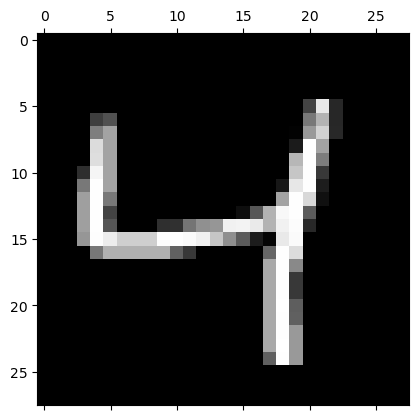

In [10]:
plt.matshow(X_train[2], cmap='gray')


In [11]:
y_train[2]

np.uint8(4)

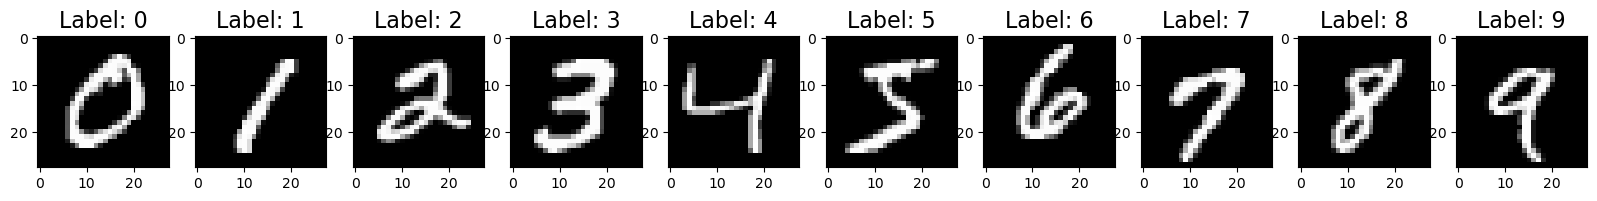

In [12]:
num_classes = 10
_, ax = plt.subplots(1, num_classes, figsize=(20, 20))
for i in range(num_classes):
    sample = X_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'Label: {i}', fontsize=16)

In [13]:
X_train.shape

(60000, 28, 28)

## Scaling Pixel Values

We scale the pixel values to the range [0, 1] for several reasons. Neural networks typically perform better with input data that is on a smaller scale. This helps in speeding up the training process since smaller values make the weight adjustments in the optimization algorithm less extreme. It also helps in preventing the model from getting stuck in local minima during training. Furthermore, scaling ensures that all input features (pixel values in this case) contribute equally to the distance computations in the learning process, thus avoiding bias towards features with larger scales.

In [14]:
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

In [15]:
for r in X_train_normalized[2]:
  for c in r:
    if c > 0:
      print(c)

0.2627450980392157
0.9098039215686274
0.15294117647058825
0.24313725490196078
0.3176470588235294
0.47058823529411764
0.7058823529411765
0.15294117647058825
0.49411764705882355
0.6392156862745098
0.00784313725490196
0.6
0.8235294117647058
0.1568627450980392
0.8627450980392157
0.6392156862745098
0.10588235294117647
0.996078431372549
0.6352941176470588
0.8705882352941177
0.6392156862745098
0.7176470588235294
0.996078431372549
0.49019607843137253
0.1803921568627451
0.9607843137254902
0.6392156862745098
0.7764705882352941
0.996078431372549
0.2196078431372549
0.47058823529411764
0.996078431372549
0.6392156862745098
0.09019607843137255
0.9058823529411765
0.996078431372549
0.11372549019607843
0.6235294117647059
0.996078431372549
0.47058823529411764
0.6392156862745098
0.996078431372549
0.8470588235294118
0.06274509803921569
0.6235294117647059
0.996078431372549
0.2627450980392157
0.054901960784313725
0.33725490196078434
0.6980392156862745
0.9725490196078431
0.996078431372549
0.3568627450980392
0

In [16]:
X_train_normalized[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [17]:
print(X_train_normalized.shape)
print(X_train_normalized.min())
print(X_train_normalized.max())

(60000, 28, 28)
0.0
1.0


## Flattening Images to 1D Arrays

In many machine learning models, including simple neural networks, the input data needs to be a flat vector of features. By converting the 2D image matrices into 1D arrays, we transform the data into a format that the neural network can work with. This is because the underlying algorithms typically expect a single list of features for each input sample, and each pixel value in the image is treated as a separate feature. This step is essential for the model to process the input image data correctly.

In [18]:
X_train_flattened = X_train_normalized.reshape(X_train.shape[0], -1)
X_test_flattened = X_test_normalized.reshape(X_test.shape[0], -1)

In [19]:
X_train_flattened = X_train_normalized.reshape(len(X_train), 28*28)
X_test_flattened = X_test_normalized.reshape(len(X_test), 28*28)

In [20]:
print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flattened.shape}")

Original shape: (60000, 28, 28)
Flattened shape: (60000, 784)


## Create an initial Neural Network using Keras

We will initially use a simple network that only has an input layer and an output layer. The input layer will have 784 neurons (28x28 pixels in each image) and the outputlayer will have 10 neurons as we want to predict a digit, 0-9 

In [21]:
model = keras.Sequential(
    [
        keras.layers.Dense(10, input_shape = (784,), activation='softmax')
    ]
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ["accuracy"]
)

model.fit(X_train_flattened, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8777 - loss: 0.4668
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9150 - loss: 0.3039
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9212 - loss: 0.2829
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9242 - loss: 0.2730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9259 - loss: 0.2665


## Lab

## 1 Prediction Generation:

How can you generate predictions from a trained neural network model using a test dataset? What function or method would you use?

Answer:

We can generate predictions from the trained model by using model.predict() on the test dataset. For example:

In [22]:
predictions = model.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## 2. Accessing Prediction Details:

How would you access the prediction details for the second image in the test dataset? Which index would you use to retrieve this information from the predictions array?

Answer:

The model.predict() function provides the prediction details. To retrieve the prediction for the second image in the test dataset, index 1 is used, since array indexing starts at 0.


In [23]:
second_image_pred = predictions[1]
print(second_image_pred)

[5.3570775e-04 4.8860184e-06 9.9240029e-01 4.2617743e-04 2.6822652e-13
 2.7183262e-03 3.7723416e-03 6.5903414e-16 1.4223516e-04 9.3374516e-13]


## 3. Finding the Predicted Class:

How can you determine the predicted class from the output of a neural network? What function would you use to find the index of the highest probability?

Answer:

The predicted class is determined by using the argmax function, which returns the index of the highest probability in the output vector. This index corresponds to the class that the neural network predicts for the image.

In [24]:
predicted_class = np.argmax(second_image_pred)
print(f"Predicted class: {predicted_class}")

Predicted class: 2


## 4. Visualizing Test Data:

Which function would you use to visualize a specific test image, and what parameters might you need to provide to display it in grayscale?

Answer:

To visualize a specific test image, the matshow() function from Matplotlib can be used. The parameter cmap='gray' is provided to display the image in grayscale.

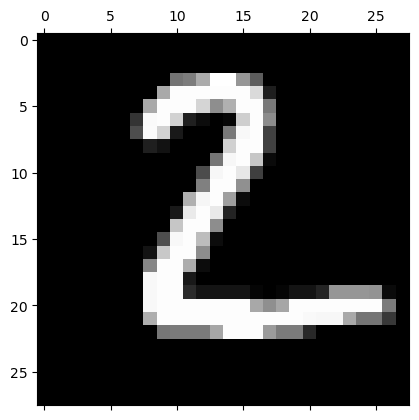

In [25]:
plt.matshow(X_test[1], cmap='gray')

## 5. Comparing with Actual Labels:

How would you retrieve the actual label for the second image in the test dataset? Which index should you use to access this information?

Answer:

The actual label for the second image in the test dataset is retrieved by accessing index 1 in the y_test array. 

In [26]:

actual_label = y_test[1]
print(f"Actual label: {actual_label}")

Actual label: 2


## 6. Converting Predictions to Class Labels:

How can you convert a list of prediction probabilities into class labels for each test image? What Python technique or method would help you iterate over the predictions and extract the labels?

Answer:

To convert prediction probabilities into class labels, the argmax() function is used to find the index of the highest probability for each prediction. In Pyhton, this can be done by applying np.argmax(predictions, axis=1) or by iterating over the predictions using list comprehension:

In [27]:
predicted_labels =  np.argmax(predictions, axis=1)
print(predicted_labels)

[7 2 1 ... 4 5 6]


In [28]:

predicted_labels = [np.argmax(p) for p in predictions]

## 7. Examining Initial Predictions:

How would you access the first five predicted class labels from your converted predictions? Which part of the list would you slice to get this subset?

Answer:

After converting the prediction probabilities into class labels, the result will be stored in a list or NumPy array. To get the first five elements, we slice from index 0 up to index 5.

In [29]:
#predicted_labels will return a list

first_five_labels = predicted_labels[0:5]
print(', '.join(str(label) for label in first_five_labels))

7, 2, 1, 0, 4


## Check against the first 10 labels

In [30]:
print(', '.join(str(c) for c in predicted_labels[:10]))
print(', '.join(str(c) for c in y_test[:10]))

7, 2, 1, 0, 4, 1, 4, 9, 6, 9
7, 2, 1, 0, 4, 1, 4, 9, 5, 9


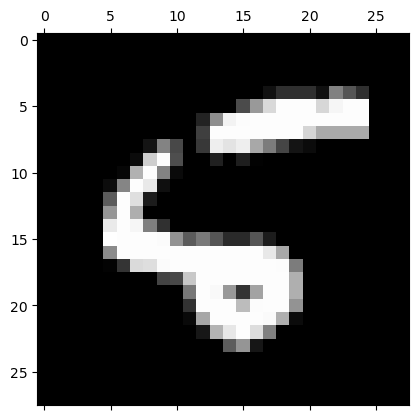

In [31]:
plt.matshow(X_test[8], cmap='gray')

## Create a confusion matrix to see how well the model performed.

In [32]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=predicted_labels)

In [33]:
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 966,    0,    1,    2,    0,    4,    4,    2,    1,    0],
       [   0, 1114,    3,    2,    0,    1,    4,    2,    9,    0],
       [   9,    9,  917,   18,    8,    3,   13,   11,   40,    4],
       [   4,    0,   17,  929,    0,   17,    3,   10,   22,    8],
       [   1,    1,    4,    1,  911,    0,   11,    4,   10,   39],
       [  11,    3,    3,   42,   10,  762,   14,    8,   34,    5],
       [  13,    3,    5,    1,    7,   10,  915,    2,    2,    0],
       [   2,    7,   22,    7,    5,    0,    0,  956,    2,   27],
       [   8,    8,    7,   23,    9,   22,    9,   12,  871,    5],
       [  11,    7,    1,   11,   22,    7,    0,   28,    7,  915]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

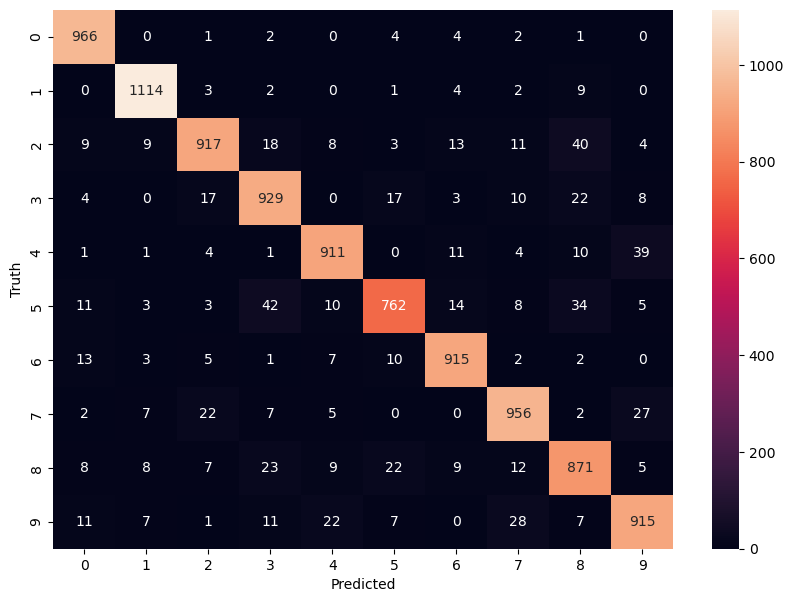

In [34]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

## Lab

## Add Hidden Layers

In [35]:
model_1 = keras.Sequential(
  [
    keras.layers.Dense(128, input_shape = (784,), activation = 'relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation = 'softmax')
  ]
)
model_1.compile(
  optimizer = 'adam',
  loss='sparse_categorical_crossentropy',
  metrics = ['accuracy']
)

model_1.fit(X_train_flattened, y_train, epochs = 5)

c:\Users\furti\miniconda3\envs\MyDjangoEnvThird\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9275 - loss: 0.2459
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9683 - loss: 0.1036
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9769 - loss: 0.0750
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9813 - loss: 0.0586
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9850 - loss: 0.0465


## Test and Evaluate

In [36]:
 # Generates predictions for all test images
predictions = model_1.predict(X_test_flattened)

# Get the index of the highest probability for each prediction
predicted_labels = np.argmax(predictions, axis=1) 

# Compare with the actual labels
for i in range(10):
  print(f"Predicted: {predicted_labels[i]}, Actual: {y_test[i]}")

print()

# Evaluete the model on test data
result = model_1.evaluate(X_test_flattened, y_test)
print(f"Test loss and accuracy: {result}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted: 7, Actual: 7
Predicted: 2, Actual: 2
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 4, Actual: 4
Predicted: 1, Actual: 1
Predicted: 4, Actual: 4
Predicted: 9, Actual: 9
Predicted: 5, Actual: 5
Predicted: 9, Actual: 9

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0783
Test loss and accuracy: [0.0782770961523056, 0.9778000116348267]


#Lab

## Experiment 1 : More Epochs

In [37]:
model_1 = keras.Sequential(
    [
        keras.layers.Dense(10, input_shape = (784,), activation='softmax')
    ]
)

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ["accuracy"]
)

model_1.fit(X_train_flattened, y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8773 - loss: 0.4705
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9161 - loss: 0.3038
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9203 - loss: 0.2837
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9240 - loss: 0.2728
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9261 - loss: 0.2663
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9272 - loss: 0.2614
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9288 - loss: 0.2585
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9291 - loss: 0.2554
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9299 - loss: 0.2530
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9308 - loss: 0.2511


In [38]:

y_predicted = model_1.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [39]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]

In [40]:
print(', '.join([str(c) for c in y_predicted_labels[:10]]))
print(', '.join([str(c) for c in y_test[:10]]))

7, 2, 1, 0, 4, 1, 4, 9, 6, 9
7, 2, 1, 0, 4, 1, 4, 9, 5, 9


In [45]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)

Text(95.72222222222221, 0.5, 'Truth')

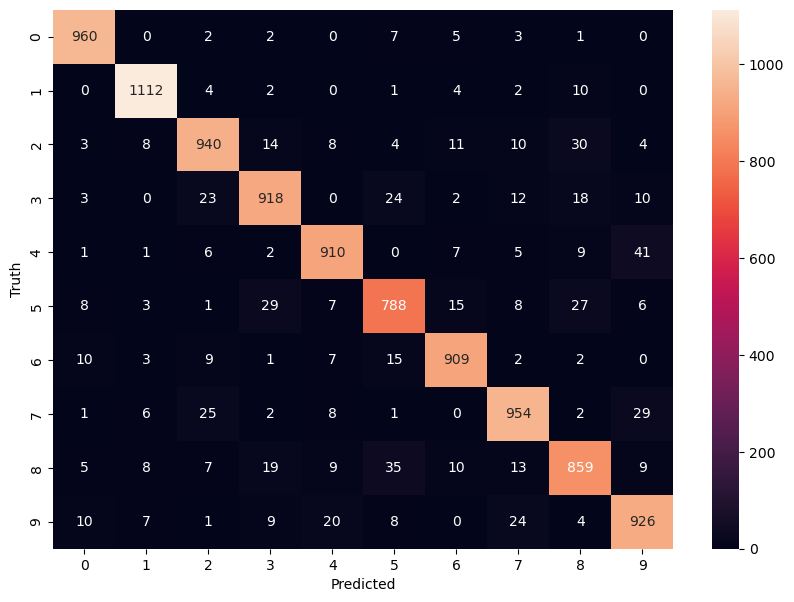

In [46]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [47]:
errors = (y_predicted_labels - y_test != 0)
y_error_indexes = [i for i, error in enumerate(errors) if error]
len(y_error_indexes)

724

## Conclusion for Experiment 1
Increasing epochs from 5 → 10 made the model predicts better. The number of errors decreased to 724.

## Experiment 2: Modify hidden layers

In [41]:
model_3 = keras.Sequential([
    keras.layers.Dense(256, input_shape=(784,), activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3.fit(X_train_flattened, y_train, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9356 - loss: 0.2129
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9715 - loss: 0.0919
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9805 - loss: 0.0631
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9850 - loss: 0.0479
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9871 - loss: 0.0401


In [42]:
test_loss, test_acc = model_3.evaluate(X_test_flattened, y_test)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9777 - loss: 0.0837
Test accuracy: 0.9776999950408936
Test loss: 0.08366655558347702


## Conclusion for Experiment 2 (hidden layers)

Increasing the number of neurons results in higher test accuracy and lower test loss.

## Experiment 3 — Use other activation function

In [43]:
model_4 = keras.Sequential([
    keras.layers.Dense(256, input_shape=(784,), activation='tanh'),
    keras.layers.Dense(128, activation='tanh'),
    keras.layers.Dense(64, activation='tanh'),
    keras.layers.Dense(10, activation='softmax')
])

model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_4.fit(X_train_flattened, y_train, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9281 - loss: 0.2387
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9647 - loss: 0.1142
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9735 - loss: 0.0834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9800 - loss: 0.0622
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9841 - loss: 0.0496


In [44]:
test_loss, test_acc = model_4.evaluate(X_test_flattened, y_test)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9737 - loss: 0.0904
Test accuracy: 0.9736999869346619
Test loss: 0.09041067212820053


## Conclusion for activation experiment

relu activation provides better performance than tanh for this dataset